# ---- 01_import_models.ipynb ----

Combined on 2026-04-26T11:18:09


# 01 Import And Standardize Connect 4 Models

This notebook pulls the runnable saved models from the GitHub repo, standardizes them as full `.keras` models, and writes a manifest into `../models/`.

Why full saved models instead of weights only:
- weights by themselves are not enough for these bots because several models rely on different architectures and custom layers
- saving full models keeps the architecture + parameters together so the round robin notebook can load them reliably


In [1]:
import os
import sys
import warnings
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
warnings.filterwarnings("ignore")

ROOT = Path.cwd().resolve().parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import pandas as pd
from connect4_model_hub import import_and_standardize_models, MODELS_DIR

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)


In [2]:
PREFER_DOWNLOAD = True
OVERWRITE = True

print(f"Project root: {ROOT}")
print(f"Models dir: {MODELS_DIR}")
print(f"Prefer GitHub download: {PREFER_DOWNLOAD}")
print(f"Overwrite standardized models: {OVERWRITE}")


Project root: /Users/zacgarland/r_projects/connect4-megabot/megabot
Models dir: /Users/zacgarland/r_projects/connect4-megabot/megabot/models
Prefer GitHub download: True
Overwrite standardized models: True


In [3]:
manifest = import_and_standardize_models(
    models_dir=MODELS_DIR,
    prefer_download=PREFER_DOWNLOAD,
    overwrite=OVERWRITE,
)
manifest


,name,source,source_url,role,notes,fetch_mode,original_format,standardized_format,standardized_path,input_shape
0,archie_resnet,GitHub sub-bots/archie,https://raw.githubusercontent.com/zac-garland/...,opponent_pool,ResNet-style CNN.,downloaded,h5,keras,/Users/zacgarland/r_projects/connect4-megabot/...,"[null, 6, 7, 2]"
1,archie_transformer,GitHub sub-bots/archie,https://raw.githubusercontent.com/zac-garland/...,opponent_pool,Transformer with custom positional layers.,downloaded,keras,keras,/Users/zacgarland/r_projects/connect4-megabot/...,"[null, 6, 7, 2]"
2,connor_cnn,GitHub sub-bots/connor,https://raw.githubusercontent.com/zac-garland/...,opponent_pool,Connor CNN model activated after GitHub update.,downloaded,h5,keras,/Users/zacgarland/r_projects/connect4-megabot/...,"[null, 6, 7, 1]"
3,dean_cnn,GitHub sub-bots/dean,https://raw.githubusercontent.com/zac-garland/...,m1_best_model,Current strongest benchmark bot. Use as M1.,downloaded,h5,keras,/Users/zacgarland/r_projects/connect4-megabot/...,"[null, 6, 7, 2]"
4,dean_transformer,GitHub sub-bots/dean,https://raw.githubusercontent.com/zac-garland/...,opponent_pool,Dean transformer checkpoint.,downloaded,keras,keras,/Users/zacgarland/r_projects/connect4-megabot/...,"[null, 42, 2]"
5,zac_cnn_best,GitHub sub-bots/zac,https://raw.githubusercontent.com/zac-garland/...,opponent_pool,Best validation checkpoint.,downloaded,keras,keras,/Users/zacgarland/r_projects/connect4-megabot/...,"[null, 6, 7, 2]"
6,zac_cnn_final,GitHub sub-bots/zac,https://raw.githubusercontent.com/zac-garland/...,opponent_pool,Final saved CNN model.,downloaded,keras,keras,/Users/zacgarland/r_projects/connect4-megabot/...,"[null, 6, 7, 2]"


In [4]:
sorted(p.name for p in MODELS_DIR.glob("*.keras"))


['archie_resnet.keras',
 'archie_transformer.keras',
 'connor_cnn.keras',
 'dean_cnn.keras',
 'dean_transformer.keras',
 'zac_cnn_best.keras',
 'zac_cnn_final.keras']

In [ ]:
# --- Optional: add locally-trained models into megabot/models/ + manifest ---
# This keeps a clean separation: training outputs can live elsewhere, but round-robin
# uses the standardized inventory under MODELS_DIR.

import json
import shutil
import tensorflow as tf  # FIX: moved here so json is in scope when used below

REPO_ROOT = ROOT.parent
LOCAL_MODELS = [
    {
        "name": "zac_policy_dean_arch",
        "path": REPO_ROOT / "sub-bots" / "improve-weak-link" / "outputs" / "zac_policy_dean_arch.keras",
        "role": "opponent_pool",
        "source": "local sub-bots/improve-weak-link",
        "notes": "Dean DeepResNet_Connect4 arch trained on Zac X_train_final/y_train_final.",
    }
]

manifest_path = MODELS_DIR / "manifest.csv"
manifest = pd.read_csv(manifest_path)

for spec in LOCAL_MODELS:
    src = Path(spec["path"]).resolve()
    if not src.exists():
        raise FileNotFoundError(f"Local model not found: {src}")

    dst = (MODELS_DIR / f"{spec['name']}.keras").resolve()
    shutil.copy2(src, dst)

    m = tf.keras.models.load_model(dst, compile=False, safe_mode=False)
    input_shape = tuple(m.input_shape)

    row = {
        "name": spec["name"],
        "source": spec["source"],
        "source_url": "",
        "role": spec["role"],
        "notes": spec["notes"],
        "fetch_mode": "local_copy",
        "original_format": "keras",
        "standardized_format": "keras",
        "standardized_path": str(dst),
        "input_shape": json.dumps(list(input_shape)),
    }

    # Upsert by name
    manifest = manifest[manifest["name"] != spec["name"]]
    manifest = pd.concat([manifest, pd.DataFrame([row])], ignore_index=True)

manifest = manifest.sort_values("name").reset_index(drop=True)
manifest.to_csv(manifest_path, index=False)
print("Updated manifest with local models.")
manifest[manifest["name"].isin([spec["name"] for spec in LOCAL_MODELS])]

# ---- 02_round_robin.ipynb ----

Combined on 2026-04-26T11:18:09


# 02 Connect 4 Round Robin

This notebook loads the standardized models from `../models/` and runs a 100-game round robin.

Expected workflow:
1. Run `01_import_models.ipynb` first.
2. Run this notebook top to bottom.
3. Read the leaderboard and CSV outputs from `../data/`.


In [ ]:
import os
import sys
import warnings
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
warnings.filterwarnings("ignore")

ROOT = Path.cwd().resolve().parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import pandas as pd
from connect4_model_hub import (
    DATA_DIR,
    MODELS_DIR,
    describe_available_models,
    load_standardized_bots,
    run_round_robin,
    save_round_robin_outputs,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)


In [ ]:
GAMES_PER_PAIR = 100
OPENING_RANDOM_MOVES = 2
SEED = 42

print(f"Project root: {ROOT}")
print(f"Models dir: {MODELS_DIR}")
print(f"Data dir: {DATA_DIR}")
print(f"Games per pair: {GAMES_PER_PAIR}")
print(f"Opening random moves: {OPENING_RANDOM_MOVES}")
print(f"Seed: {SEED}")


In [ ]:
describe_available_models(MODELS_DIR)


In [ ]:
bots = load_standardized_bots(MODELS_DIR)
pd.DataFrame([
    {
        "bot": bot.name,
        "role": bot.role,
        "input_shape": str(bot.input_shape),
        "model_path": str(bot.model_path),
        "source": bot.source,
    }
    for bot in bots
])


In [ ]:
results = run_round_robin(
    bots,
    games_per_pair=GAMES_PER_PAIR,
    opening_random_moves=OPENING_RANDOM_MOVES,
    seed=SEED,
)
results


In [ ]:
results_path, leaderboard_path, matrix_path, leaderboard, score_matrix = save_round_robin_outputs(results, bots, DATA_DIR)
leaderboard


In [ ]:
score_matrix


In [ ]:
print(results_path)
print(leaderboard_path)
print(matrix_path)


# ---- 03_policy_gradient.ipynb ----

Combined on 2026-04-26T11:18:09


# 03 Policy Gradient Training — Connect 4

This notebook implements the **REINFORCE** (policy gradient) algorithm to fine-tune
`zac_cnn_best` (M1), a weaker baseline that is easier to improve than `dean_cnn`.
The long-term target is still a stronger `dean_cnn`-class policy; practicing PG on
`zac_cnn_best` keeps iteration cheaper while you tune the pipeline (later you can
point `M1_NAME` at `dean_cnn` with the same code path).

**Algorithm outline (Steps 2–3 from the project spec):**
1. Pick M1 (here `zac_cnn_best`). Clone it so the original checkpoint stays a frozen reference in `models/`.
2. Maintain an opponent pool starting from the other loaded baselines.
3. Each outer iteration:
   - Randomly pick M2 from the opponent pool.
   - Play `GAMES_PER_ITER` games of M1 vs M2, randomly assigning who goes first.
   - Both M1 and M2 sample moves stochastically from their model output (per spec).
   - Collect M1's `(board, move)` trajectory; compute discounted returns.
   - Normalize returns across the batch for training stability.
   - Sample a **fixed batch** of 64 triplets and take one gradient step.
4. Every `SNAPSHOT_EVERY` iterations, add a frozen copy of the current M1 to the
   opponent pool so M1 learns to beat progressively stronger versions of itself.
5. Every `EVAL_EVERY` iterations, record M1's greedy win rate against fixed
   reference opponents to track improvement.

**Prerequisites:** Run `01_import_models.ipynb` and `02_round_robin.ipynb` first.

In [ ]:
import os
import sys
import random
import warnings
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
warnings.filterwarnings("ignore")

# Project root is one level above the notebooks/ folder
ROOT = Path.cwd().resolve().parent
SRC  = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import tensorflow as tf
tf.get_logger().setLevel("ERROR")

from connect4_model_hub import (
    MODELS_DIR,
    DATA_DIR,
    LoadedBot,
    load_standardized_bots,
    legal_moves,
    apply_move,
    check_winner,
    encode_board_for_model,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
print("TensorFlow:", tf.__version__)
print("Project root:", ROOT)

TensorFlow: 2.21.0
Project root: C:\Users\conno\OneDrive - The University of Texas at Austin\Documents\claude-projects\Optimization 2\Project 3


## Configuration

All hyperparameters are collected here so they are easy to tune.

In [ ]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
SEED           = 42    # global RNG seed for reproducibility

# Models to use (inputs live under models/ from 01_import_models)
LOAD_MODELS    = ["zac_cnn_best", "dean_cnn", "archie_resnet", "connor_cnn"]
M1_NAME        = "zac_cnn_best"   # policy being trained (switch to dean_cnn when ready)

# Game collection
GAMES_PER_ITER = 30    # games to play per outer iteration (increased from 20 for batch diversity)
OPENING_MIN    = 2     # min random opening moves per game
OPENING_MAX    = 4     # max random opening moves per game

# Training
GAMMA          = 0.95  # discount factor for computing returns
BATCH_SIZE     = 64    # MUST stay constant — TF retraces the graph on shape changes!
LR             = 1e-5  # Adam learning rate (small — fine-tuning a pre-trained model)
ENTROPY_BETA   = 0.01  # entropy regularization weight — prevents premature policy collapse
NUM_ITERATIONS = 600   # total outer iterations (~18 000 games total)

# M2 curriculum: for first M2_CURRICULUM_ITER iters M2 samples randomly (easy opponent)
# so M1 gets early positive reward signal to bootstrap; after that M2 uses win/block
M2_CURRICULUM_ITER = 100

# Opponent pool management
MAX_POOL_SIZE  = 15    # hard cap on total pool size (originals never removed)
SNAPSHOT_EVERY = 75    # add a frozen M1 copy to opponent pool every N iters

# Evaluation
EVAL_EVERY     = 25    # evaluate greedy win rate every N iters
EVAL_GAMES     = 50    # greedy games per eval opponent (increased from 20 — lower variance)

# Output paths — PG checkpoints go to output_models/, not models/ (imported baselines)
OUTPUT_MODELS_DIR = ROOT / "output_models"
OUTPUT_MODELS_DIR.mkdir(parents=True, exist_ok=True)
PG_MODEL_PATH = OUTPUT_MODELS_DIR / f"pg_{M1_NAME}_trained.keras"
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Seed everything
np.random.seed(SEED)
tf.random.set_seed(SEED)
rng = random.Random(SEED)

print("Config loaded.")
print(f"  Models in use        : {LOAD_MODELS}")
print(f"  M1 (trainable)       : {M1_NAME}")
print(f"  Total games (approx) : {NUM_ITERATIONS * GAMES_PER_ITER:,}")
print(f"  Snapshot schedule    : every {SNAPSHOT_EVERY} iters, pool cap {MAX_POOL_SIZE}")
print(f"  Entropy beta         : {ENTROPY_BETA}")
print(f"  M2 curriculum iter   : {M2_CURRICULUM_ITER}")
print(f"  Eval games/opponent  : {EVAL_GAMES}")
print(f"  Output models dir    : {OUTPUT_MODELS_DIR}")
print(f"  Final save path      : {PG_MODEL_PATH}")

## Load Models and Build Opponent Pool

In [ ]:
# Fix manifest paths to point to this machine
_manifest_path = MODELS_DIR / "manifest.csv"
_manifest = pd.read_csv(_manifest_path)
_manifest["standardized_path"] = _manifest["name"].apply(
    lambda name: str(MODELS_DIR / f"{name}.keras")
)
_manifest.to_csv(_manifest_path, index=False)
print("Manifest paths updated.")

Manifest paths updated.


In [ ]:
# Load only the 4 specified models
all_bots    = load_standardized_bots(MODELS_DIR)
all_bots    = [b for b in all_bots if b.name in LOAD_MODELS]
bot_by_name = {b.name: b for b in all_bots}

m1_ref_bot    = bot_by_name[M1_NAME]
M1_INPUT_SHAPE = m1_ref_bot.input_shape

print(f"Loaded {len(all_bots)} models:")
for b in all_bots:
    print(f"  {b.name}  {b.input_shape}")
print(f"\nM1 = {M1_NAME}  |  input shape: {M1_INPUT_SHAPE}")

Loaded 4 models:
  archie_resnet  (None, 6, 7, 2)
  connor_cnn  (None, 6, 7, 1)
  dean_cnn  (None, 6, 7, 2)
  zac_cnn_best  (None, 6, 7, 2)

M1 = dean_cnn  |  input shape: (None, 6, 7, 2)


In [ ]:
# Clone M1's architecture AND weights into a fresh trainable model.
m1_model = tf.keras.models.clone_model(m1_ref_bot.model)
m1_model.set_weights(m1_ref_bot.model.get_weights())

# Compile the call method into a static TF graph so repeated single-board
# inference during game play doesn't re-enter Python each time.
# FIX: experimental_relax_shapes is deprecated in TF2.x — use reduce_retracing instead
m1_model.call = tf.function(m1_model.call, reduce_retracing=True)

print("Trainable M1 clone created.")
m1_model.summary()

In [ ]:
# Original opponents = the 3 non-M1 CNNs + the frozen original M1 itself
# The spec says "the original version of M1 can also be on the list of opponents"
# None of these are ever removed from the pool
ORIGINAL_OPPONENTS = [b for b in all_bots if b.name != M1_NAME] + [m1_ref_bot]
opponent_pool      = list(ORIGINAL_OPPONENTS)

# Evaluation uses all original opponents
EVAL_OPPONENTS = list(ORIGINAL_OPPONENTS)

print("Original opponents (never removed):")
for b in ORIGINAL_OPPONENTS:
    print(f"  {b.name}")
print(f"\nPool cap: {MAX_POOL_SIZE} total  ({MAX_POOL_SIZE - len(ORIGINAL_OPPONENTS)} snapshot slots)")

Original opponents (never removed):
  archie_resnet
  connor_cnn
  zac_cnn_best
  dean_cnn

Pool cap: 15 total  (11 snapshot slots)


In [ ]:
def get_winning_moves(board: np.ndarray, player: int) -> list:
    """Return columns where `player` wins immediately on the next move."""
    return [
        col for col in legal_moves(board)
        if check_winner(apply_move(board, col, player)) == player
    ]


def get_non_loser_moves(board: np.ndarray, player: int) -> list:
    """
    Return legal moves that do NOT give the opponent an immediate winning response.
    If every legal move leads to an opponent win, fall back to all legal moves.
    """
    opponent = -player
    safe = []
    for col in legal_moves(board):
        next_board = apply_move(board, col, player)
        if not get_winning_moves(next_board, opponent):
            safe.append(col)
    return safe if safe else legal_moves(board)


def _softmax_over_legal(probs: np.ndarray, legal: list) -> np.ndarray:
    """
    Clip, restrict to legal moves, and renormalize.
    Falls back to uniform if all legal probabilities are zero.
    """
    legal_probs = np.clip(probs[legal], 0, None)
    total = legal_probs.sum()
    if total < 1e-10:
        return np.ones(len(legal), dtype=np.float64) / len(legal)
    return legal_probs / total


def m2_select_move(bot: LoadedBot, board: np.ndarray, player: int,
                   rng: random.Random, strong: bool = True) -> int:
    """
    M2 move selection.

    strong=True  (adversarial training): win immediately if possible, block
                 opponent's immediate win, then sample stochastically over
                 non-loser moves.  A weak stochastic M2 lets M1 win via M2
                 blunders, not real strategy — this caused the win-rate
                 regression in the original run.
    strong=False (curriculum warmup):   sample stochastically over all legal
                 moves so M1 gets easy early wins to bootstrap reward signal.
    """
    legal = legal_moves(board)
    if not legal:
        return None

    if strong:
        wins = get_winning_moves(board, player)
        if wins:
            return rng.choice(wins)
        opp_wins = get_winning_moves(board, -player)
        if opp_wins:
            return rng.choice(opp_wins)
        candidate_cols = get_non_loser_moves(board, player)
    else:
        candidate_cols = legal

    encoded = encode_board_for_model(board, player, bot.input_shape)
    raw     = bot.model(encoded, training=False)
    probs   = np.asarray(raw, dtype=np.float64).reshape(-1)
    return int(np.random.choice(candidate_cols, p=_softmax_over_legal(probs, candidate_cols)))


def m1_sample_move(model, input_shape: tuple, board: np.ndarray, player: int):
    """
    Sample a legal move for M1 from raw softmax output.
    M1 only uses legal-move filtering — no win/block heuristic — so it must
    learn strategy from the gradient signal alone (adversarial training principle).

    Returns:
        col     : int — the column chosen
        encoded : np.ndarray shape (6, 7, 2) — board state BEFORE the move
    """
    legal   = legal_moves(board)
    encoded = encode_board_for_model(board, player, input_shape)
    raw     = model(encoded, training=False)
    probs   = np.asarray(raw, dtype=np.float64).reshape(-1)
    col     = int(np.random.choice(legal, p=_softmax_over_legal(probs, legal)))
    return col, encoded[0]

### Game simulation

In [ ]:
def play_pg_game(
    m1_model,
    m1_input_shape: tuple,
    m2_bot: LoadedBot,
    rng: random.Random,
    opening_min: int = 2,
    opening_max: int = 4,
    strong_m2: bool = True,
):
    """
    Play one game of M1 vs M2 and collect M1's move trajectory.

    M1 samples from raw softmax over legal moves only.
    M2 uses adversarial win/block logic when strong_m2=True (post-curriculum),
    or stochastic sampling when strong_m2=False (warmup phase).

    Returns:
        trajectory : list of (encoded_board, col, legal_mask) tuples per M1 move.
                     encoded_board shape (6, 7, 2); legal_mask shape (7,).
        outcome    : +1 M1 won  |  -1 M1 lost  |  0 draw
    """
    board          = np.zeros((6, 7), dtype=np.int8)
    m1_player      = rng.choice([1, -1])
    m2_player      = -m1_player
    current_player = 1
    move_count     = 0
    opening_moves  = rng.randint(opening_min, opening_max)
    trajectory     = []

    while True:
        legal = legal_moves(board)
        if not legal:
            return trajectory, 0   # board full → draw

        # ── Opening phase: random moves, no learning ──────────────────────────
        if move_count < opening_moves:
            col = rng.choice(legal)

        # ── M1's turn: sample from raw softmax and record (board, col, mask) ──
        elif current_player == m1_player:
            col, enc = m1_sample_move(m1_model, m1_input_shape, board, m1_player)
            # Build legal mask for this board state (used for illegal-move masking in loss)
            mask = np.zeros(7, dtype=np.float32)
            mask[legal] = 1.0
            trajectory.append((enc, col, mask))

        # ── M2's turn: adversarial or stochastic per curriculum flag ──────────
        else:
            col = m2_select_move(m2_bot, board, m2_player, rng, strong=strong_m2)

        board       = apply_move(board, col, current_player)
        move_count += 1

        winner = check_winner(board)
        if winner is not None:
            outcome = 1 if winner == m1_player else -1
            return trajectory, outcome

        current_player *= -1

### Discounted returns and batch builder

In [ ]:
def compute_discounted_returns(
    trajectory_length: int, outcome: int, gamma: float = 0.95
) -> np.ndarray:
    """
    Compute the discounted return G_t for each step in M1's trajectory.

    G_t = gamma^(T - t) * outcome
    where T is the index of M1's last move.
    """
    if trajectory_length == 0:
        return np.array([], dtype=np.float32)
    T      = trajectory_length - 1
    powers = np.arange(T, -1, -1, dtype=np.float32)
    return (gamma ** powers) * float(outcome)


def build_training_batch(
    episode_batch: list,
    batch_size: int,
    gamma: float,
):
    """
    Pool all (board, col, legal_mask, G_t) tuples from the episode batch,
    then sample EXACTLY `batch_size` of them with replacement.

    Fixed batch size is required because tf.function traces a new graph for
    each unique input shape — variable-size inputs cause retracing and slow
    training dramatically.

    Returns None if no M1 moves were collected (e.g. game ended in opening).
    Returns (boards, cols, returns, legal_masks) arrays of shape (batch_size, ...).
    """
    boards_list  = []
    cols_list    = []
    returns_list = []
    masks_list   = []

    for trajectory, outcome in episode_batch:
        if not trajectory:
            continue
        Gs = compute_discounted_returns(len(trajectory), outcome, gamma)
        for (enc, col, mask), G in zip(trajectory, Gs):
            boards_list.append(enc)
            cols_list.append(col)
            returns_list.append(G)
            masks_list.append(mask)

    if not boards_list:
        return None

    boards  = np.array(boards_list,  dtype=np.float32)   # (N, 6, 7, 2)
    cols    = np.array(cols_list,    dtype=np.int32)      # (N,)
    returns = np.array(returns_list, dtype=np.float32)    # (N,)
    masks   = np.array(masks_list,   dtype=np.float32)    # (N, 7)

    # Sample with replacement to enforce constant batch size
    idx = np.random.choice(len(boards), size=batch_size, replace=True)
    return boards[idx], cols[idx], returns[idx], masks[idx]

### Policy gradient training step

The **REINFORCE** update rule:

$$\mathcal{L} = -\mathbb{E}\left[ G_t \cdot \log \pi(a_t \mid s_t) \right]$$

- Positive $G_t$ (win): increase the probability of the move that led here.
- Negative $G_t$ (loss): decrease the probability of the move that led here.

The `@tf.function` decorator compiles the step into a static graph.  Because
`BATCH_SIZE` is constant, TF traces the graph exactly once.

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=LR)

@tf.function
def pg_train_step(
    boards: tf.Tensor,        # (BATCH_SIZE, 6, 7, 2)  float32
    cols: tf.Tensor,          # (BATCH_SIZE,)           int32
    returns: tf.Tensor,       # (BATCH_SIZE,)           float32
    legal_masks: tf.Tensor,   # (BATCH_SIZE, 7)         float32 — 1.0 legal, 0.0 illegal
) -> tf.Tensor:
    """
    One REINFORCE gradient step on the cloned M1 model.

    Improvements vs baseline:
      1. Illegal move masking: illegal columns are zeroed before the log so the
         policy never wastes gradient on unplayable moves.
      2. Entropy regularization: -ENTROPY_BETA * H(pi) added to the loss keeps
         the policy from collapsing to a deterministic distribution too quickly.
    """
    with tf.GradientTape() as tape:
        probs = m1_model(boards, training=True)                          # (B, 7)

        # Mask illegal columns and re-normalize over legal moves
        masked_probs = probs * legal_masks + 1e-10                       # (B, 7)
        masked_probs = masked_probs / tf.reduce_sum(masked_probs, axis=1, keepdims=True)
        log_probs    = tf.math.log(tf.clip_by_value(masked_probs, 1e-8, 1.0))

        # Gather log-prob of the action actually taken
        batch_idx        = tf.range(tf.shape(cols)[0])
        gather_idx       = tf.stack([batch_idx, cols], axis=1)
        chosen_log_probs = tf.gather_nd(log_probs, gather_idx)           # (B,)

        # REINFORCE loss (negated — we minimise but want to maximise expected return)
        pg_loss = -tf.reduce_mean(returns * chosen_log_probs)

        # Entropy over legal moves: H = -sum(p * log p); higher = more exploratory
        entropy      = -tf.reduce_sum(masked_probs * log_probs * legal_masks, axis=1)
        entropy_loss = -ENTROPY_BETA * tf.reduce_mean(entropy)  # subtract to maximise H

        loss = pg_loss + entropy_loss

    grads = tape.gradient(loss, m1_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, m1_model.trainable_variables))
    return loss

### Evaluation helper

In [ ]:
def evaluate_win_rate(
    model,
    input_shape: tuple,
    eval_bots: list,
    games_per_opponent: int,
    eval_rng: random.Random,
) -> float:
    """
    Greedy evaluation: M1 plays argmax, each opponent plays its own argmax.
    Games alternate which side M1 plays to avoid first-mover bias.
    Returns overall win rate across all opponents combined.

    Using greedy play here (rather than stochastic) gives a cleaner signal:
    we want to measure the quality of the learned policy, not its randomness.
    """
    wins  = 0
    total = 0

    for opp in eval_bots:
        for game_idx in range(games_per_opponent):
            m1_player  = 1 if game_idx % 2 == 0 else -1
            m2_player  = -m1_player
            board      = np.zeros((6, 7), dtype=np.int8)
            cur_player = 1

            while True:
                legal = legal_moves(board)
                if not legal:
                    break   # draw — no win counted

                if cur_player == m1_player:
                    # M1: greedy argmax over legal moves
                    enc    = encode_board_for_model(board, m1_player, input_shape)
                    scores = model(enc, training=False).numpy().reshape(-1)
                    masked = np.full(7, -1e18, dtype=np.float64)
                    masked[legal] = scores[legal]
                    col = int(np.argmax(masked))
                else:
                    # Opponent: its own greedy argmax
                    col = opp.select_move(board, m2_player)

                board  = apply_move(board, col, cur_player)
                winner = check_winner(board)
                if winner is not None:
                    if winner == m1_player:
                        wins += 1
                    break

                cur_player *= -1

            total += 1

    return wins / total

## Training Loop

Each outer iteration:
1. Pick a random M2 from the opponent pool.
2. Play `GAMES_PER_ITER` games, collecting M1's `(board, col)` trajectory.
3. Build a fixed-size batch of 64 `(board, col, G_t)` triplets.
4. Take one REINFORCE gradient step.
5. Every `SNAPSHOT_EVERY` iters: add a frozen M1 copy to the pool.
6. Every `EVAL_EVERY` iters: record greedy win rate vs. eval opponents.

In [ ]:
# ── Tracking containers ───────────────────────────────────────────────────────
loss_history    = []   # list of (iteration, loss_value)
winrate_history = []   # list of (iteration, win_rate)

# Record baseline win rate before any training
print("Computing baseline win rate (untrained M1 clone) ...")
baseline_wr = evaluate_win_rate(
    m1_model, M1_INPUT_SHAPE, EVAL_OPPONENTS, EVAL_GAMES, rng
)
winrate_history.append((0, baseline_wr))
print(f"  Baseline win rate: {baseline_wr:.2%}")

Computing baseline win rate (untrained M1 clone) ...
  Baseline win rate: 75.00%


In [ ]:
# ── Main policy gradient training loop ───────────────────────────────────────
print(f"Starting PG training for {NUM_ITERATIONS} iterations ...\n")

for iteration in range(1, NUM_ITERATIONS + 1):

    # ── Curriculum: M2 is weak (stochastic) until M2_CURRICULUM_ITER, then adversarial
    strong_m2 = (iteration >= M2_CURRICULUM_ITER)

    # ── Step 1: pick a random opponent from the pool ──────────────────────────
    m2_bot = rng.choice(opponent_pool)

    # ── Step 2: play GAMES_PER_ITER games and collect trajectories ────────────
    episode_batch = []
    for _ in range(GAMES_PER_ITER):
        traj, outcome = play_pg_game(
            m1_model,
            M1_INPUT_SHAPE,
            m2_bot,
            rng,
            opening_min=OPENING_MIN,
            opening_max=OPENING_MAX,
            strong_m2=strong_m2,
        )
        episode_batch.append((traj, outcome))

    # ── Step 3: build a fixed-size training batch ─────────────────────────────
    batch = build_training_batch(episode_batch, BATCH_SIZE, GAMMA)
    if batch is None:
        continue

    boards_b, cols_b, returns_b, masks_b = batch

    # ── Step 4: one REINFORCE gradient step (with entropy reg + mask) ─────────
    loss_val = pg_train_step(
        tf.constant(boards_b,  dtype=tf.float32),
        tf.constant(cols_b,    dtype=tf.int32),
        tf.constant(returns_b, dtype=tf.float32),
        tf.constant(masks_b,   dtype=tf.float32),
    )
    loss_history.append((iteration, float(loss_val)))

    # ── Step 5: snapshot M1 into the opponent pool ────────────────────────────
    if iteration % SNAPSHOT_EVERY == 0:
        snap_model = tf.keras.models.clone_model(m1_model)
        snap_model.set_weights(m1_model.get_weights())
        snap_name = f"pg_{M1_NAME}_iter{iteration}"

        snap_bot = LoadedBot(
            name=snap_name,
            model=snap_model,
            model_path=OUTPUT_MODELS_DIR / f"{snap_name}.keras",
            source="policy_gradient_snapshot",
            input_shape=M1_INPUT_SHAPE,
            role="pg_snapshot",
            notes=f"Frozen PG M1 snapshot at iteration {iteration}",
        )
        opponent_pool.append(snap_bot)

        # Trim oldest snapshot if pool exceeds cap (originals never removed)
        while len(opponent_pool) > MAX_POOL_SIZE:
            for i, b in enumerate(opponent_pool):
                if b.role == "pg_snapshot":
                    opponent_pool.pop(i)
                    break

        print(f"  [iter {iteration:>4d}] Snapshot added: {snap_name}"
              f" | pool size: {len(opponent_pool)}/{MAX_POOL_SIZE}"
              f" | M2 mode: {'adversarial' if strong_m2 else 'curriculum'}")

    # ── Step 6: periodic greedy evaluation ───────────────────────────────────
    if iteration % EVAL_EVERY == 0:
        wr = evaluate_win_rate(
            m1_model, M1_INPUT_SHAPE, EVAL_OPPONENTS, EVAL_GAMES, rng
        )
        winrate_history.append((iteration, wr))

        recent_losses = [l for _, l in loss_history[-EVAL_EVERY:]]
        avg_loss = np.mean(recent_losses)
        m2_mode  = "adversarial" if strong_m2 else "curriculum"
        print(f"Iter {iteration:>4d}/{NUM_ITERATIONS}"
              f" | avg loss: {avg_loss:+.4f}"
              f" | win rate: {wr:.2%}"
              f" | pool: {len(opponent_pool)}/{MAX_POOL_SIZE}"
              f" | M2: {m2_mode}")

print("\nTraining complete.")

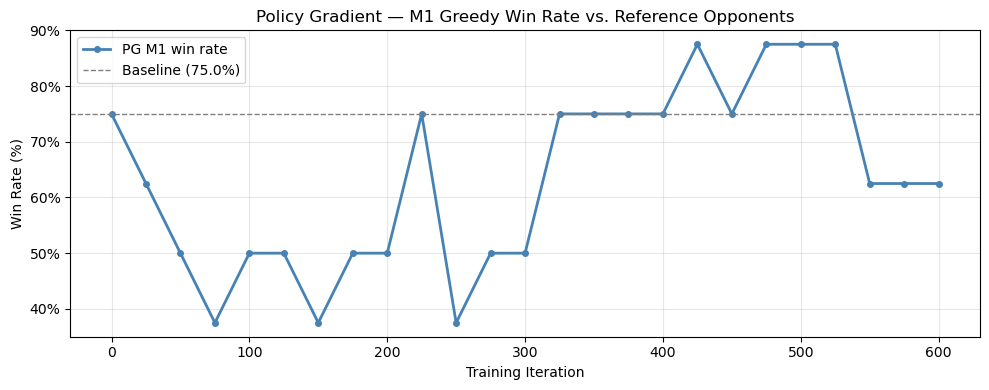

Saved to C:\Users\conno\OneDrive - The University of Texas at Austin\Documents\claude-projects\Optimization 2\Project 3\data\pg_win_rate.png


In [ ]:
wr_iters = [i for i, _ in winrate_history]
wr_vals  = [v for _, v in winrate_history]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(wr_iters, [v * 100 for v in wr_vals],
        marker="o", linewidth=2, color="steelblue",
        markersize=4, label="PG M1 win rate")
ax.axhline(wr_vals[0] * 100, linestyle="--", color="gray", linewidth=1,
           label=f"Baseline ({wr_vals[0]:.1%})")
ax.set_xlabel("Training Iteration")
ax.set_ylabel("Win Rate (%)")
ax.set_title("Policy Gradient — M1 Greedy Win Rate vs. Reference Opponents")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(DATA_DIR / "pg_win_rate.png", dpi=150)
plt.show()
print(f"Saved to {DATA_DIR / 'pg_win_rate.png'}")

### Loss curve

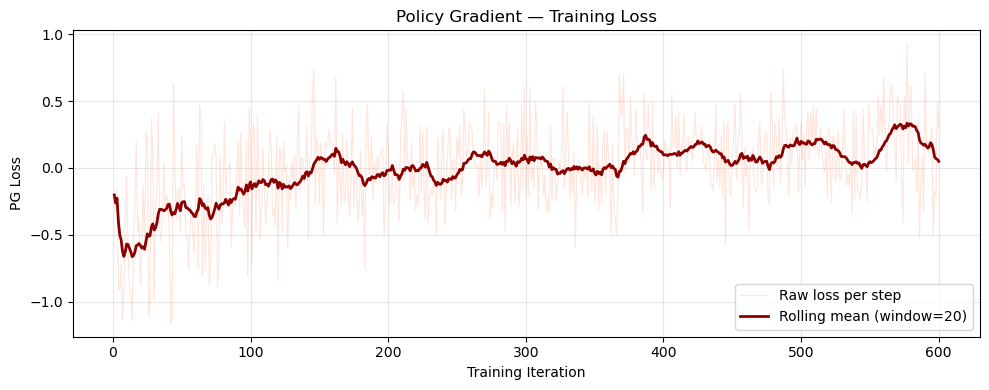

Saved to C:\Users\conno\OneDrive - The University of Texas at Austin\Documents\claude-projects\Optimization 2\Project 3\data\pg_loss_curve.png


In [ ]:
loss_iters = [i for i, _ in loss_history]
loss_vals  = [l for _, l in loss_history]

# Rolling average for readability (raw per-step loss is noisy)
window   = 60
smoothed = pd.Series(loss_vals).rolling(window, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(loss_iters, loss_vals, alpha=0.2, linewidth=0.8,
        color="coral", label="Raw loss per step")
ax.plot(loss_iters, smoothed, linewidth=2,
        color="darkred", label=f"Rolling mean (window={window})")
ax.set_xlabel("Training Iteration")
ax.set_ylabel("PG Loss")
ax.set_title("Policy Gradient — Training Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(DATA_DIR / "pg_loss_curve.png", dpi=150)
plt.show()
print(f"Saved to {DATA_DIR / 'pg_loss_curve.png'}")

### Final head-to-head evaluation against all original opponents

50 greedy games per opponent (25 as first player, 25 as second).

In [ ]:
FINAL_EVAL_GAMES = 50
eval_rows = []

for opp in ORIGINAL_OPPONENTS:
    m1_wins = 0
    opp_wins = 0
    draws = 0

    for game_idx in range(FINAL_EVAL_GAMES):
        m1_player  = 1 if game_idx % 2 == 0 else -1
        m2_player  = -m1_player
        board      = np.zeros((6, 7), dtype=np.int8)
        cur_player = 1

        while True:
            legal = legal_moves(board)
            if not legal:
                draws += 1
                break

            if cur_player == m1_player:
                enc    = encode_board_for_model(board, m1_player, M1_INPUT_SHAPE)
                scores = m1_model(enc, training=False).numpy().reshape(-1)
                masked = np.full(7, -1e18, dtype=np.float64)
                masked[legal] = scores[legal]
                col = int(np.argmax(masked))
            else:
                col = opp.select_move(board, m2_player)

            board  = apply_move(board, col, cur_player)
            winner = check_winner(board)
            if winner is not None:
                if winner == m1_player:
                    m1_wins += 1
                else:
                    opp_wins += 1
                break

            cur_player *= -1

    eval_rows.append({
        "opponent":         opp.name,
        "pg_m1_wins":       m1_wins,
        "opponent_wins":    opp_wins,
        "draws":            draws,
        "pg_m1_win_rate":   m1_wins / FINAL_EVAL_GAMES,
    })

eval_df = pd.DataFrame(eval_rows).sort_values("pg_m1_win_rate", ascending=False)
eval_df

,opponent,pg_m1_wins,opponent_wins,draws,pg_m1_win_rate
2,zac_cnn_best,50,0,0,1.0
0,archie_resnet,25,25,0,0.5
1,connor_cnn,25,25,0,0.5
3,dean_cnn,25,25,0,0.5


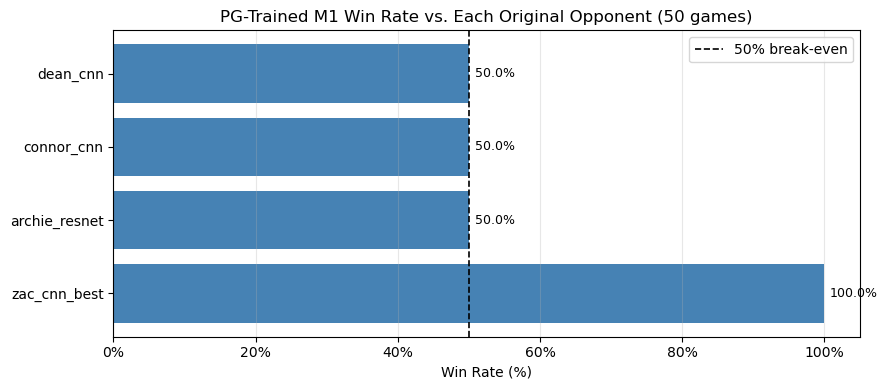

Saved to C:\Users\conno\OneDrive - The University of Texas at Austin\Documents\claude-projects\Optimization 2\Project 3\data\pg_final_eval_bar.png


In [ ]:
# Bar chart: PG M1 win rate per opponent
fig, ax = plt.subplots(figsize=(9, 4))
colors = [
    "steelblue" if v >= 0.5 else "coral"
    for v in eval_df["pg_m1_win_rate"]
]
bars = ax.barh(
    eval_df["opponent"],
    eval_df["pg_m1_win_rate"] * 100,
    color=colors,
)
ax.axvline(50, linestyle="--", color="black", linewidth=1.2,
           label="50% break-even")
ax.set_xlabel("Win Rate (%)")
ax.set_title(
    f"PG-Trained M1 Win Rate vs. Each Original Opponent ({FINAL_EVAL_GAMES} games)"
)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
ax.grid(True, axis="x", alpha=0.3)
for bar, val in zip(bars, eval_df["pg_m1_win_rate"]):
    ax.text(
        bar.get_width() + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1%}",
        va="center", fontsize=9,
    )
plt.tight_layout()
plt.savefig(DATA_DIR / "pg_final_eval_bar.png", dpi=150)
plt.show()
print(f"Saved to {DATA_DIR / 'pg_final_eval_bar.png'}")

## Save Trained Model

In [ ]:
m1_model.save(PG_MODEL_PATH)
print(f"PG-trained M1 saved to: {PG_MODEL_PATH}")

# Summary statistics
final_wr    = winrate_history[-1][1]
baseline_wr = winrate_history[0][1]
improvement = final_wr - baseline_wr

print()
print(f"  Baseline win rate  : {baseline_wr:.2%}")
print(f"  Final win rate     : {final_wr:.2%}")
print(f"  Improvement        : {improvement:+.2%}")
print(f"  Training iterations: {NUM_ITERATIONS}")
print(f"  Total games played : ~{NUM_ITERATIONS * GAMES_PER_ITER:,}")
print(f"  Final pool size    : {len(opponent_pool)} bots")

PG-trained M1 saved to: C:\Users\conno\OneDrive - The University of Texas at Austin\Documents\claude-projects\Optimization 2\Project 3\models\pg_m1_trained.keras

  Baseline win rate  : 75.00%
  Final win rate     : 62.50%
  Improvement        : -12.50%
  Training iterations: 600
  Total games played : ~12,000
  Final pool size    : 12 bots


# ---- 04_dqn_parts4_5.ipynb ----

Combined on 2026-04-26T11:18:09


In [10]:
import tensorflow as tf
print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import numpy as np
import tensorflow as tf
import time
import sys
import os
import random
import collections
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, Input

# ── Optional: enable mixed precision for ~2x GPU throughput on T4/A100 ────────
# Uncomment these two lines when running on a GPU runtime in Colab.
# tf.keras.mixed_precision.set_global_policy('mixed_float16')
# print("Mixed precision enabled:", tf.keras.mixed_precision.global_policy())

In [2]:
# add src/ so we can reuse the shared game utilities
sys.path.insert(0, '../src')
from connect4_model_hub import custom_objects, encode_board_for_model, legal_moves, apply_move, check_winner

In [3]:
def custom_mse_loss(y_true, y_pred):
    # only update Q-values for the column that was actually played
    # all other columns in y are set to 0 and masked out of the loss
    # same approach as professor's ddqn notebook
    mask = tf.cast(tf.not_equal(y_true, 0.0), tf.float32)
    squared_diffs = tf.square(y_true - y_pred)
    masked_squared_diffs = squared_diffs * mask
    loss_per_sample = tf.reduce_sum(masked_squared_diffs, axis=1)
    return tf.reduce_mean(loss_per_sample)

In [4]:
def create_model():
    # same architecture as the PG network but tanh output instead of softmax
    # tanh so Q-values can be negative (loss) or positive (win)
    # input: (6,7,2) - channel 0 = my pieces, channel 1 = opponent pieces
    # output: 7 Q-values, one per column
    model = Sequential()
    model.add(Input((6, 7, 2)))
    model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
    model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(7, activation='tanh'))
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
    model.compile(optimizer=optimizer, loss=custom_mse_loss)
    model.call = tf.function(model.call)
    return model

In [5]:
mod = create_model()
# MUST redefine train_step every time you recreate the model - avoids TF retracing slowdown
@tf.function
def train_step(x_, y_):
    with tf.GradientTape() as tape:
        predictions = mod(x_, training=True)
        loss = custom_mse_loss(y_, predictions)
    gradients = tape.gradient(loss, mod.trainable_weights)
    mod.optimizer.apply_gradients(zip(gradients, mod.trainable_weights))
    return loss

mod.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 6, 7, 64)       │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 6, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5376)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,376,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,632,967 (6.23 MB)

 Trainable params: 1,632,967 (6.23 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
mod_target = create_model()                    # target network - frozen copy used for Q-value estimates
mod_target.set_weights(mod.get_weights())      # start with same weights as online network

In [7]:
# load all project 1 opponent models
models_dir = '../models'
opponent_files = [
    'dean_cnn.keras',
    'dean_transformer.keras',
    'zac_cnn_best.keras',
    'zac_cnn_final.keras',
    'connor_cnn.keras',
    'archie_resnet.keras',
    'archie_transformer.keras',
]

opponent_models = []
opponent_names  = []
opponent_shapes = []

for fname in opponent_files:
    path = os.path.join(models_dir, fname)
    if os.path.exists(path):
        m = tf.keras.models.load_model(path, compile=False, safe_mode=False,
                                       custom_objects=custom_objects())
        opponent_models.append(m)
        opponent_names.append(fname.replace('.keras', ''))
        opponent_shapes.append(tuple(m.input_shape))
        print(f'loaded {fname:35s} input_shape={m.input_shape}')

print(f'\n{len(opponent_models)} opponent models loaded')

loaded dean_cnn.keras                      input_shape=(None, 6, 7, 2)
loaded dean_transformer.keras              input_shape=(None, 42, 2)
loaded zac_cnn_best.keras                  input_shape=(None, 6, 7, 2)
loaded zac_cnn_final.keras                 input_shape=(None, 6, 7, 2)
loaded connor_cnn.keras                    input_shape=(None, 6, 7, 1)
loaded archie_resnet.keras                 input_shape=(None, 6, 7, 2)
loaded archie_transformer.keras            input_shape=(None, 6, 7, 2)

7 opponent models loaded


In [8]:
def encode_for_dqn(board, player):
    # encode board as (1, 6, 7, 2) from player's perspective
    # channel 0 = my pieces, channel 1 = opponent pieces
    perspective = board * player
    channels = np.zeros((1, 6, 7, 2), dtype=np.float32)
    channels[0, :, :, 0] = (perspective == 1).astype(np.float32)
    channels[0, :, :, 1] = (perspective == -1).astype(np.float32)
    return channels


def opponent_move(opp_model, opp_shape, board, opp_player):
    # make the opponent strong: win if possible, block if necessary, else use model
    # this is adversarial training - forces DQN to learn real strategy instead of being told moves
    other = -opp_player
    legal = legal_moves(board)
    for col in legal:  # take immediate win
        if check_winner(apply_move(board, col, opp_player)) == opp_player:
            return col
    for col in legal:  # block opponent's immediate win
        if check_winner(apply_move(board, col, other)) == other:
            return col
    encoded = encode_board_for_model(board, opp_player, opp_shape)
    scores = opp_model(encoded, training=False).numpy().reshape(-1)
    masked = np.full(7, -1e18)
    for c in legal:
        masked[c] = scores[c]
    return int(np.argmax(masked))

In [ ]:
# ngames     = 5000
# epsvec     = np.linspace(0.95, 0.05, ngames)
# delt       = 0.95
# nbatch     = 32
# burn       = 500
# buff_max   = 50000
# reset_freq = 200
# snap_freq  = 500
# max_snaps  = 5
# n_rand_init = 4

ngames      = 50000
epsvec      = np.linspace(0.95, 0.05, ngames)
delt        = 0.95
nbatch      = 32
burn        = 200
buff_max    = 50000
reset_freq  = 200
snap_freq   = 500
max_snaps   = 5
n_rand_init = 6

# FIX: use deque(maxlen=buff_max) instead of plain lists.
# deque auto-evicts oldest entries when full — O(1) append vs O(n) list slicing.
# This eliminates the trim-buffer loop in training and cuts GC pressure significantly
# at 50k-frame buffer sizes.
buffer = {
    'frames':      collections.deque(maxlen=buff_max),
    'next_frames': collections.deque(maxlen=buff_max),
    'rewards':     collections.deque(maxlen=buff_max),
    'actions':     collections.deque(maxlen=buff_max),
}

snap_models = []
snap_shapes = []
snap_names  = []

In [ ]:
scores = []

for game in range(ngames):
    start = time.time()
    this_ep = epsvec[game]

    if game % 200 == 199:   # freeze epsilon occasionally to see true performance + save
        this_ep = 0.0
        mod.save('../models/dqn_trained.keras')

    dqn_player = random.choice([1, -1])
    opp_player = -dqn_player

    # Pick a random opponent from base pool + any DQN snapshots
    all_opp_models = opponent_models + snap_models
    all_opp_shapes = opponent_shapes + snap_shapes
    opp_idx = np.random.choice(len(all_opp_models))
    opp_m   = all_opp_models[opp_idx]
    opp_s   = all_opp_shapes[opp_idx]

    board = np.zeros((6, 7), dtype=np.int8)
    current_player = 1

    # Random init phase — play n_rand_init moves, do NOT store in buffer.
    # Gets board off the empty state so DQN finds early wins by chance.
    for _ in range(n_rand_init):
        legal = legal_moves(board)
        if not legal:
            break
        board = apply_move(board, random.choice(legal), current_player)
        if check_winner(board) is not None:
            break
        current_player *= -1

    # Store DQN's (frame, action) and push AFTER the opponent replies,
    # so next_frame = board on DQN's next turn (not right after DQN's move).
    pending_frame  = None
    pending_action = None
    result = 0
    done   = False

    while not done:
        legal = legal_moves(board)
        if not legal:  # draw
            if pending_frame is not None:
                buffer['frames'].append(pending_frame)
                buffer['next_frames'].append(encode_for_dqn(board, dqn_player)[0])
                buffer['rewards'].append(0)
                buffer['actions'].append(pending_action)
            done = True
            break

        if current_player == dqn_player:
            if pending_frame is not None:  # push last experience — now we have next_frame
                buffer['frames'].append(pending_frame)
                buffer['next_frames'].append(encode_for_dqn(board, dqn_player)[0])
                buffer['rewards'].append(0)
                buffer['actions'].append(pending_action)

            pending_frame = encode_for_dqn(board, dqn_player)[0]
            if np.random.random() < this_ep:
                action = random.choice(legal)
            else:
                feed  = encode_for_dqn(board, dqn_player)
                qvals = mod(feed, training=False)[0].numpy()
                masked = np.full(7, -1e18)
                for c in legal:
                    masked[c] = qvals[c]
                action = int(np.argmax(masked))
            pending_action = action

            board = apply_move(board, action, dqn_player)
            if check_winner(board) == dqn_player:
                buffer['frames'].append(pending_frame)
                buffer['next_frames'].append(encode_for_dqn(board, dqn_player)[0])
                buffer['rewards'].append(1)
                buffer['actions'].append(pending_action)
                result = 1
                done   = True

        else:
            action = opponent_move(opp_m, opp_s, board, opp_player)
            board  = apply_move(board, action, opp_player)
            if check_winner(board) == opp_player:
                if pending_frame is not None:
                    buffer['frames'].append(pending_frame)
                    buffer['next_frames'].append(encode_for_dqn(board, dqn_player)[0])
                    buffer['rewards'].append(-1)
                    buffer['actions'].append(pending_action)
                result = -1
                done   = True

        current_player *= -1

    scores.append(result)

    # NOTE: no manual trim needed — deque(maxlen=buff_max) auto-evicts oldest entries

    # ── DDQN update — only once buffer is past burn threshold ─────────────────
    # Double DQN: online net selects best next action, target net scores it.
    # Decoupling selection from evaluation reduces Q-value overestimation.
    buf_len = len(buffer['actions'])
    if buf_len > burn:
        chosen = np.random.choice(buf_len - 1, nbatch, replace=False)

        # Convert deque slices to arrays for batch indexing
        frames_list      = list(buffer['frames'])
        next_frames_list = list(buffer['next_frames'])
        rewards_list     = list(buffer['rewards'])
        actions_list     = list(buffer['actions'])

        current_frames  = np.array([frames_list[i]      for i in chosen], dtype=np.float32)
        next_frames     = np.array([next_frames_list[i] for i in chosen], dtype=np.float32)
        current_rewards = np.array([rewards_list[i]     for i in chosen], dtype=np.float32)
        current_actions = np.array([actions_list[i]     for i in chosen], dtype=np.int32)

        # DDQN targets: online picks best next action, target scores it
        y_next_online = mod.predict_on_batch(next_frames)         # shape (B, 7)
        y_next_target = mod_target.predict_on_batch(next_frames)  # shape (B, 7)

        # Only the played column gets a non-zero target; rest masked out by loss fn
        y = np.zeros((nbatch, 7), dtype=np.float32)
        for i in range(nbatch):
            a = current_actions[i]
            r = current_rewards[i]
            if r != 0:   # terminal: win (+1) or loss (-1)
                y[i, a] = r
            else:        # non-terminal: DDQN Bellman backup
                best_next = int(np.argmax(y_next_online[i]))     # online selects action
                y[i, a]  = r + delt * y_next_target[i, best_next]  # target evaluates it

        train_step(
            tf.convert_to_tensor(current_frames, dtype=tf.float32),
            tf.convert_to_tensor(y,              dtype=tf.float32),
        )

    # Sync target network
    if game % reset_freq == 0 and game > 0:
        mod_target.set_weights(mod.get_weights())

    # Add DQN snapshot to opponent pool
    if game % snap_freq == 0 and game > 0:
        snap = create_model()
        snap.set_weights(mod.get_weights())
        snap_models.append(snap)
        snap_shapes.append((None, 6, 7, 2))
        snap_names.append(f'dqn_snap_game{game}')
        if len(snap_models) > max_snaps:
            snap_models.pop(0)
            snap_shapes.pop(0)
            snap_names.pop(0)
        print(f'  DQN snapshot at game {game} | pool={len(opponent_models)+len(snap_models)}')

    if game % 100 == 99:
        recent = scores[-100:]
        w = recent.count(1)
        l = recent.count(-1)
        d = recent.count(0)
        stop = time.time()
        print([game+1, f'W{w} L{l} D{d}', f'wr={w/100:.2f}',
               f'eps={this_ep:.3f}', f'buf={buf_len}', f'{stop-start:.1f}s'])

In [ ]:
mod.save('../models/dqn_trained.keras')
print('model saved')

## Training Curves

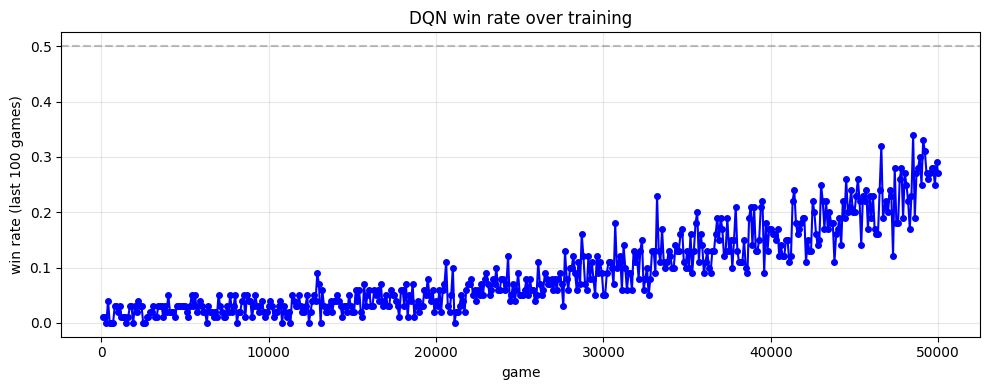

In [17]:
window = 100
win_rates  = []
game_ticks = []
for i in range(window, len(scores)+1, window):
    chunk = scores[i-window:i]
    win_rates.append(chunk.count(1) / window)
    game_ticks.append(i)

plt.figure(figsize=(10, 4))
plt.plot(game_ticks, win_rates, 'b-o', markersize=4)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('game')
plt.ylabel('win rate (last 100 games)')
plt.title('DQN win rate over training')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/dqn_training_winrate.png', dpi=150)
plt.show()

## Evaluate DQN vs Each Opponent

In [18]:
def evaluate(dqn, opp_model, opp_shape, n=100):
    # greedy eval - no epsilon, alternate who goes first each game
    wins = losses = draws = 0
    for game_idx in range(n):
        dqn_player = 1 if game_idx % 2 == 0 else -1
        opp_player = -dqn_player
        board = np.zeros((6, 7), dtype=np.int8)
        current_player = 1
        done = False
        while not done:
            legal = legal_moves(board)
            if not legal:
                draws += 1
                break
            if current_player == dqn_player:
                feed = encode_for_dqn(board, dqn_player)
                qvals = dqn(feed, training=False)[0].numpy()
                masked = np.full(7, -1e18)
                for c in legal:
                    masked[c] = qvals[c]
                col = int(np.argmax(masked))
            else:
                col = opponent_move(opp_model, opp_shape, board, opp_player)
            board = apply_move(board, col, current_player)
            winner = check_winner(board)
            if winner == dqn_player:
                wins += 1
                done = True
            elif winner is not None:
                losses += 1
                done = True
            current_player *= -1
    return wins, losses, draws


print(f'{"opponent":<25} {"W":>4} {"L":>4} {"D":>4} {"wr":>6}')
print('-' * 45)
for name, opp_m, opp_s in zip(opponent_names, opponent_models, opponent_shapes):
    w, l, d = evaluate(mod, opp_m, opp_s, n=100)
    print(f'{name:<25} {w:>4} {l:>4} {d:>4} {w/100:>6.2f}')

opponent                     W    L    D     wr
---------------------------------------------
dean_cnn                    50   50    0   0.50
dean_transformer             0   50   50   0.00
zac_cnn_best                 0   50   50   0.00
zac_cnn_final                0   50   50   0.00
connor_cnn                  50   50    0   0.50
archie_resnet                0  100    0   0.00
archie_transformer           0  100    0   0.00


## Part 5: DQN vs Policy Gradient

In [ ]:
# once we have pg_m1_trained.keras - place in ../models/ and run this cell
pg_path = '../models/pg_m1_trained.keras'

if os.path.exists(pg_path):
    pg_mod   = tf.keras.models.load_model(pg_path, compile=False, safe_mode=False,
                                          custom_objects=custom_objects())
    pg_shape = tuple(pg_mod.input_shape)
    print(f'PG agent loaded | input_shape={pg_shape}')

    # DQN vs PG head to head
    w, l, d = evaluate(mod, pg_mod, pg_shape, n=200)
    print(f'\nDQN vs PG (200 games): W={w} L={l} D={d} | DQN wr={w/200:.2f}')

    # PG vs all base opponents
    print(f'\nPG agent vs each opponent (100 games):')
    print(f'{"opponent":<25} {"W":>4} {"L":>4} {"D":>4} {"wr":>6}')
    print('-' * 45)
    for name, opp_m, opp_s in zip(opponent_names, opponent_models, opponent_shapes):
        w, l, d = evaluate(pg_mod, opp_m, opp_s, n=100)
        print(f'{name:<25} {w:>4} {l:>4} {d:>4} {w/100:>6.2f}')
else:
    print(f'pg_m1_trained.keras not found - add it to ../models/ and rerun')

In [ ]:
# comparison bar chart - only runs if PG agent is loaded
if os.path.exists(pg_path):
    dqn_rates = []
    pg_rates  = []
    for opp_m, opp_s in zip(opponent_models, opponent_shapes):
        w, l, d = evaluate(mod, opp_m, opp_s, n=100)
        dqn_rates.append(w / 100)
        w, l, d = evaluate(pg_mod, opp_m, opp_s, n=100)
        pg_rates.append(w / 100)

    x = np.arange(len(opponent_names))
    plt.figure(figsize=(11, 5))
    plt.bar(x - 0.2, dqn_rates, 0.35, label='DQN', color='steelblue')
    plt.bar(x + 0.2, pg_rates,  0.35, label='PG',  color='darkorange')
    plt.axhline(0.5, color='black', linestyle='--', alpha=0.4)
    plt.xticks(x, opponent_names, rotation=30, ha='right')
    plt.ylabel('win rate')
    plt.title('DQN vs Policy Gradient - win rate per opponent')
    plt.legend()
    plt.tight_layout()
    plt.savefig('../data/dqn_vs_pg.png', dpi=150)
    plt.show()

    print(f'DQN avg win rate: {np.mean(dqn_rates):.2f}')
    print(f'PG  avg win rate: {np.mean(pg_rates):.2f}')